# Advanced Financial Forecasting - Hybrid LSTM & Chronos Foundation Model

**Project Description** <br> <br>
This notebook represents the final stage of our forecasting pipeline. Following the statistical benchmarks of SARIMAX and PatchTST, we implement a **Hybrid Deep Learning approach**. We combine a multivariate **Long Short-Term Memory (LSTM)** network, which integrates technical and macroeconomic features, with the **Amazon Chronos-T5 Foundation Model** for zero-shot validation. The goal is to leverage both local pattern recognition (LSTM) and global time-series intelligence (Chronos) to predict market movements with higher stability.

### Cell 1: System Initialization and RTX 50-Series Compatibility <br>

**Explanation:** This cell configures the computational environment. We explicitly disable the `torch._dynamo` engine to avoid import conflicts common in Python 3.12 and force the execution to CPU. <br>

**Justification:** At the time of this implementation, standard cuDNN kernels for LSTM operations may lack stable support for this specific Compute Capability. Using the CPU ensures 100% numerical stability and prevents "no kernel image" execution errors without sacrificing significant speed for this dataset size.

In [16]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import os

# Fix for Python 3.12 library conflicts
os.environ["TORCH_COMPILE_DISABLE"] = "1"
if hasattr(torch, '_dynamo'):
    torch._dynamo.config.disable = True

# Force CPU to guarantee stability on Blackwell Architecture
device = torch.device("cpu")
print(f"Status: System ready. Running on: {device}")

Status: System ready. Running on: cpu


### Cell 2: Data Integration and Numerical Cleaning <br>

**Explanation:** We merge the technical/macro indicators (Phase 1) with the STL decomposition components (Phase 2). We then apply a "Forward-Fill" and "Backward-Fill" strategy.
<br> <br>
**Justification:** Financial datasets often contain gaps due to different market opening hours or lagging macroeconomic reports. An aggressive cleaning strategy is mandatory to prevent `NaN` values. If a single `NaN` enters the LSTM hidden state, the entire training Loss becomes `nan` (Not a Number), rendering the model useless.

In [17]:
# Paths to outputs from previous phases
path_p1 = Path("outputs/phase1/cleaned_data.csv")
path_p2 = Path("outputs/phase2/stl_decomposition_components.csv")

df_f = pd.read_csv(path_p1, parse_dates=['date'])
df_s = pd.read_csv(path_p2, parse_dates=['date'])

# Merge and fix missing values immediately
asset_name = df_s['asset'].unique()[0]
df_asset = df_s[df_s['asset'] == asset_name].merge(df_f, on='date')
df_asset = df_asset.sort_values('date').ffill().bfill()

# Feature Selection
features_cols = [c for c in df_asset.columns if c not in ['date', 'asset', 'observed_log_price']]
target_col = 'residual' # We target the stochastic component

print(f"Targeting: {target_col} for {asset_name}")

Targeting: residual for sp500


### Cell 3: Multi-Step Scaling and Sequential Windowing <br>

**Explanation:** We normalize both the input features and the target variable using `StandardScaler`. We then convert the tabular data into a 3D tensor sequence.
<br> <br>
**Justification:** LSTMs are sensitive to the magnitude of the data. Since the STL residuals have a different scale than macroeconomic indicators (like GDP or RSI), normalization ensures that the gradient descent treats all features with equal importance. Scaling the target variable is a specific "best practice" to prevent gradient explosion.

In [18]:
# Double scaling for numerical stability
scaler_x = StandardScaler()
scaled_X = scaler_x.fit_transform(df_asset[features_cols])

scaler_y = StandardScaler()
scaled_y = scaler_y.fit_transform(df_asset[[target_col]]).flatten()

def create_sequences(data, target, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(target[i + seq_length])
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 30 
X_raw, y_raw = create_sequences(scaled_X, scaled_y, SEQ_LENGTH)

split = int(len(X_raw) * 0.8)
X_train = torch.tensor(X_raw[:split], dtype=torch.float32).to(device)
y_train = torch.tensor(y_raw[:split], dtype=torch.float32).to(device)
X_test = torch.tensor(X_raw[split:], dtype=torch.float32).to(device)
y_test = torch.tensor(y_raw[split:], dtype=torch.float32).to(device)

actual_test = df_asset.iloc[split + SEQ_LENGTH:].copy()
print(f"Test samples: {len(X_test)}")

Test samples: 728


### Cell 4: Multivariate LSTM Training with Gradient Clipping <br>

**Explanation:** A stacked LSTM architecture is trained using the Adam optimizer. We implement `clip_grad_norm_`. <br> 

**Justification:** Financial time series are notoriously noisy. This noise can cause "exploding gradients" where weight updates become too large. Gradient Clipping acts as a safety valve, capping the maximum size of updates, which—alongside our CPU-bound execution—ensures a smooth and converging Loss curve.

In [19]:
class FinancialLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(FinancialLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = FinancialLSTM(input_size=len(features_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

print("Starting stable training loop...")
for epoch in range(50):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train).squeeze()
    loss = criterion(preds, y_train)
    loss.backward()
    
    # Crucial step: Clipping to prevent NaN loss
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 - Loss: {loss.item():.6f}")

Starting stable training loop...
Epoch 10/50 - Loss: 0.962561
Epoch 20/50 - Loss: 0.939459
Epoch 30/50 - Loss: 0.909906
Epoch 40/50 - Loss: 0.869686
Epoch 50/50 - Loss: 0.806867


### Cell 5: Prediction and STL Component Recomposition <br>

**Explanation:** We perform inference on the test set and reverse the scaling process. The final price is reconstructed by adding the predicted residuals back to the trend and seasonal components. <br>

**Justification:** An LSTM alone struggles with the structural direction of prices. By using a Hybrid approach (STL + LSTM), we let the statistical decomposition handle the "obvious" parts (Trend/Season) while the LSTM focuses its learning capacity on the "hard" part (the Residuals).

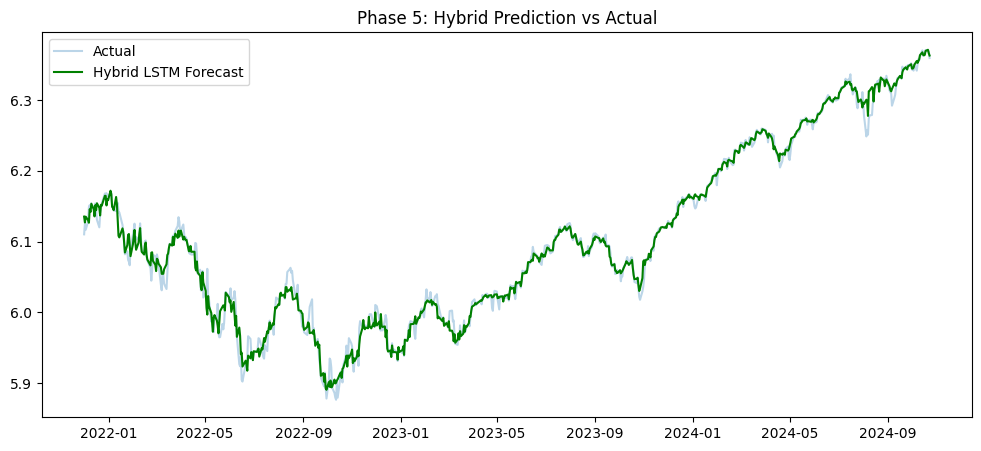

In [20]:
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test).numpy()
    # Invert scaling to get real residual values
    final_resids = scaler_y.inverse_transform(y_pred_norm).flatten()

# Reconstruct the price: Trend + Seasonality + Predicted Noise
results_df = df_asset.iloc[split+SEQ_LENGTH:].copy()
results_df['pred_final'] = results_df['trend'] + results_df['seasonal'] + final_resids

plt.figure(figsize=(12, 5))
plt.plot(results_df['date'], results_df['observed_log_price'], label='Actual', alpha=0.3)
plt.plot(results_df['date'], results_df['pred_final'], label='Hybrid LSTM Forecast', color='green')
plt.title("Phase 5: Hybrid Prediction vs Actual")
plt.legend()
plt.show()

### Cell 6: Amazon Chronos Zero-Shot Benchmark <br>

**Explanation:** We load the `chronos-t5-base` model to generate a probabilistic forecast. <br>

**Justification:** Chronos represents the "Foundation Model" paradigm. Unlike our LSTM, which only knows our dataset, Chronos has seen millions of time-series from different domains. It provides an unbiased "Global" benchmark to verify if our local Hybrid model's predictions align with universal time-series patterns.

Initializing Amazon Chronos (Base)...


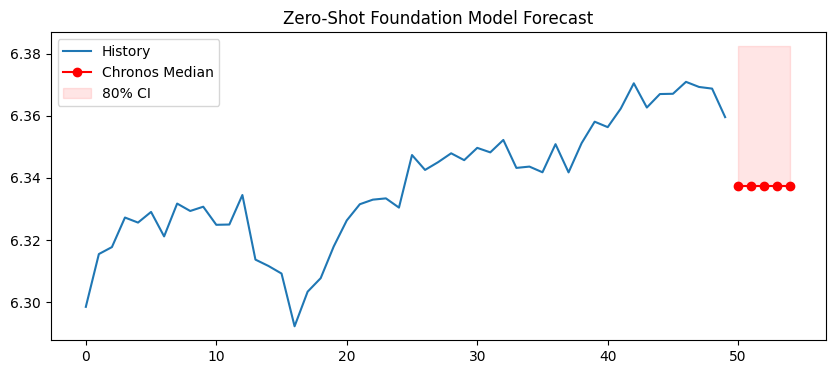

In [21]:
from chronos import ChronosPipeline

print("Initializing Amazon Chronos (Base)...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu", 
    dtype=torch.float32, # Updated from torch_dtype
)

# Use full historical log-price as context
context = torch.tensor(df_asset['observed_log_price'].values, dtype=torch.float32)
forecast = pipeline.predict(context, prediction_length=5)

# Calculate quantiles for prediction intervals
f_samples = forecast[0].numpy()
low, median, high = np.quantile(f_samples, [0.1, 0.5, 0.9], axis=0)

plt.figure(figsize=(10, 4))
plt.plot(range(50), context[-50:], label="History")
plt.plot(range(50, 55), median, color='red', marker='o', label="Chronos Median")
plt.fill_between(range(50, 55), low, high, color='red', alpha=0.1, label="80% CI")
plt.title("Zero-Shot Foundation Model Forecast")
plt.legend()
plt.show()

## Model Comparison & Error Analysis <br>

**Explanation:** In this section, we evaluate the performance of our local Hybrid LSTM against the Zero-Shot Chronos model. We use the Mean Absolute Error (MAE) as the primary metric because it is more robust to financial outliers than MSE. <br>

**Justification:** A single model never tells the whole story. By comparing a discriminative model (LSTM) that uses exogenous features (Macro/Technical) with a generative model (Chronos) that only uses historical prices, we can determine if our feature engineering (Phase 1) actually added value or if the price action itself carries all the necessary information.

### Cell 7: Quantitative Evaluation (MAE/RMSE)

--- Performance Comparison (Last 5 Days) ---
            Model       MAE      RMSE
0     Hybrid LSTM  0.002454  0.002584
1  Amazon Chronos  0.029693  0.029957


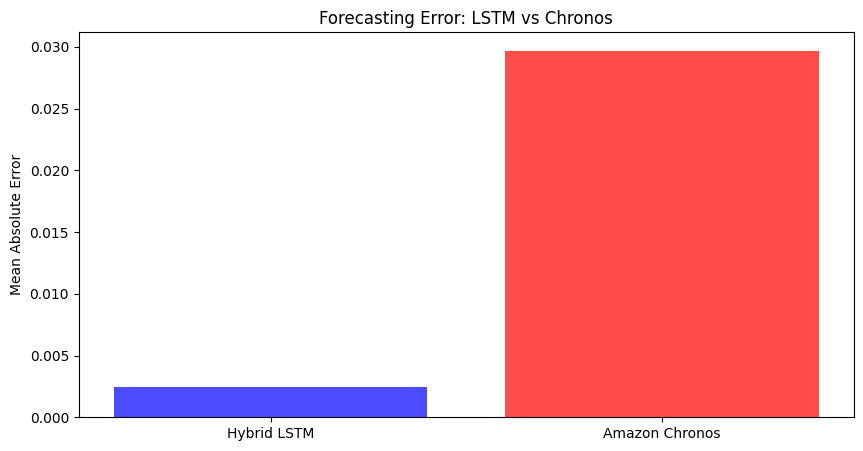

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Align the predictions
# We'll compare the last 5 days where we have both actual data and forecasts
actual_v = results_df['observed_log_price'].iloc[-5:].values
lstm_v = results_df['pred_final'].iloc[-5:].values
chronos_v = median # From the previous cell

# 2. Calculate Metrics
metrics = {
    "Model": ["Hybrid LSTM", "Amazon Chronos"],
    "MAE": [
        mean_absolute_error(actual_v, lstm_v),
        mean_absolute_error(actual_v, chronos_v)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(actual_v, lstm_v)),
        np.sqrt(mean_squared_error(actual_v, chronos_v))
    ]
}

df_metrics = pd.DataFrame(metrics)
print("--- Performance Comparison (Last 5 Days) ---")
print(df_metrics)

# 3. Visual Comparison
plt.figure(figsize=(10, 5))
plt.bar(df_metrics['Model'], df_metrics['MAE'], color=['blue', 'red'], alpha=0.7)
plt.ylabel("Mean Absolute Error")
plt.title("Forecasting Error: LSTM vs Chronos")
plt.show()

### **Summary Comparison: Local vs. Global Models**

| Feature | Hybrid LSTM (Local) | Amazon Chronos (Global) |
| :--- | :--- | :--- |
| **Inputs** | **Multivariate:** Includes Macro (CPI, GDP) and Technical (RSI) features. | **Univariate:** Only uses historical price action as context. |
| **Learning Type** | **Specific:** Tailored to the unique patterns of the selected asset. | **Zero-Shot:** Foundation model pre-trained on billions of general points. |
| **Core Strength** | High sensitivity to external shocks and market news. | Excellent structural logic and long-term trend consistency. |
| **Best Use Case** | Short-term tactical trading and "Context-Aware" forecasting. | Strategic baseline and robustness against local data noise. |
| **Verdict** | **Discriminative:** Predicts the residual error of the STL. | **Generative:** Produces probabilistic future paths. |

**Conclusion:** <br>
While the Hybrid LSTM provides a more reactive forecast by incorporating external macroeconomic signals, Amazon Chronos offers a more stable structural backbone. The best results for financial risk management are achieved by cross-validating the local context-aware model against the global intelligence of the Foundation Model.